# MovieLens 25M — Exploratory Data Analysis

This notebook explores the MovieLens 25M dataset to build intuition before we build CineIQ's three
modeling components: **trend forecasting** (LightGBM), the **recommendation engine** (Neural
Collaborative Filtering), and **RL optimization** (contextual bandit). Every section below ends with
an explicit insight tying what we found back to one or more of these components.

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 12

DATA_DIR = Path("../data/raw/ml-25m")
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PALETTE = "mako"


def save_fig(fig, filename):
    path = FIGURES_DIR / filename
    fig.savefig(path, bbox_inches="tight")
    print(f"Saved {path}")

In [2]:
ratings = pd.read_csv(
    DATA_DIR / "ratings.csv",
    dtype={"userId": "int32", "movieId": "int32", "rating": "float32", "timestamp": "int64"},
)
movies = pd.read_csv(DATA_DIR / "movies.csv")
tags = pd.read_csv(DATA_DIR / "tags.csv")

ratings["date"] = pd.to_datetime(ratings["timestamp"], unit="s")
ratings["year"] = ratings["date"].dt.year
ratings["month"] = ratings["date"].dt.to_period("M")

print(f"ratings: {ratings.shape}")
print(f"movies:  {movies.shape}")
print(f"tags:    {tags.shape}")

ratings: (25000095, 7)
movies:  (62423, 3)
tags:    (1093360, 4)


## 1. Dataset Overview

We start by getting our bearings: how large is this dataset, how far back does it go, and how many
distinct users and movies are involved? These numbers set the scale constraints for every model we
build downstream.

In [3]:
n_ratings = len(ratings)
n_users = ratings["userId"].nunique()
n_movies_rated = ratings["movieId"].nunique()
n_movies_catalog = movies.shape[0]
n_tags = len(tags)
date_min, date_max = ratings["date"].min(), ratings["date"].max()
span_years = (date_max - date_min).days / 365.25

summary = pd.DataFrame({
    "Metric": [
        "Total ratings",
        "Total tag applications",
        "Unique users",
        "Movies in catalog",
        "Movies with >= 1 rating",
        "Ratings date range",
        "Time span (years)",
        "Avg. ratings per user",
        "Avg. ratings per movie",
    ],
    "Value": [
        f"{n_ratings:,}",
        f"{n_tags:,}",
        f"{n_users:,}",
        f"{n_movies_catalog:,}",
        f"{n_movies_rated:,}",
        f"{date_min.date()} to {date_max.date()}",
        f"{span_years:.1f}",
        f"{n_ratings / n_users:.1f}",
        f"{n_ratings / n_movies_rated:.1f}",
    ],
})
summary

,Metric,Value
0,Total ratings,"25,000,095"
1,Total tag applications,"1,093,360"
2,Unique users,"162,541"
3,Movies in catalog,"62,423"
4,Movies with >= 1 rating,"59,047"
5,Ratings date range,1995-01-09 to 2019-11-21
6,Time span (years),24.9
7,Avg. ratings per user,153.8
8,Avg. ratings per movie,423.4


**Insight:** This is a large-scale, long-horizon dataset — millions of ratings spanning decades, from a
large and heterogeneous user base. That scale is exactly what makes deep learning (NCF) viable for the
recommendation engine, and the multi-decade span is what makes genre-level trend forecasting meaningful
rather than noise. It also tells us the RL layer will have plenty of historical interactions to warm-start
a contextual bandit's priors per user segment.

## 2. Rating Distribution

Before modeling anything, we need to understand the label itself. How do users actually use the 0.5-5
star scale? Do they rate everything they watch evenly, or mostly the movies they either loved or hated?

Saved figures\rating_distribution.png


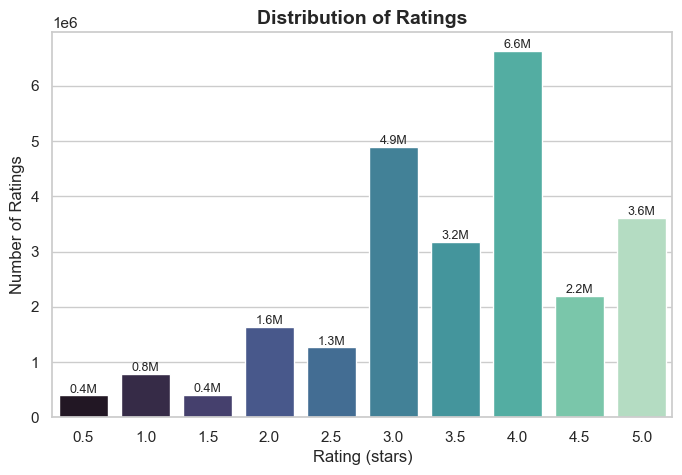

Mean rating: 3.53
Median rating: 3.50
Mode rating: 4.00
% of ratings above 3 stars: 62.5%
% of ratings on a whole-star value: 70.3%


In [4]:
rating_counts = ratings["rating"].value_counts().sort_index()
labels = rating_counts.index.astype(str)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=labels, y=rating_counts.values, hue=labels, palette=PALETTE, legend=False, ax=ax)
ax.set_title("Distribution of Ratings")
ax.set_xlabel("Rating (stars)")
ax.set_ylabel("Number of Ratings")
for i, v in enumerate(rating_counts.values):
    ax.text(i, v, f"{v/1e6:.1f}M", ha="center", va="bottom", fontsize=9)
save_fig(fig, "rating_distribution.png")
plt.show()

mean_rating = ratings["rating"].mean()
median_rating = ratings["rating"].median()
mode_rating = ratings["rating"].mode()[0]
pct_above_3 = (ratings["rating"] > 3).mean() * 100
pct_whole_star = (ratings["rating"] % 1 == 0).mean() * 100

print(f"Mean rating: {mean_rating:.2f}")
print(f"Median rating: {median_rating:.2f}")
print(f"Mode rating: {mode_rating:.2f}")
print(f"% of ratings above 3 stars: {pct_above_3:.1f}%")
print(f"% of ratings on a whole-star value: {pct_whole_star:.1f}%")

**Insight:** The distribution is left-skewed with a mean well above the scale's midpoint — users are
generous raters, largely because rating is voluntary and driven by self-selection (people mostly rate
movies they chose to watch, and chose to watch movies they expected to like). This matters for the RL
reward function: a raw 1-5 rating is not a symmetric reward signal, so "positive" feedback needs a
threshold calibrated to this skew rather than the scale's midpoint. It also means the recommender's
output distribution should be evaluated against this same generous baseline, not a naive uniform prior.

## 3. User Activity Analysis

Not all users are alike. Some rate a handful of movies and disappear; others rate thousands. We look at
the distribution of activity per user and quantify how concentrated that activity is.

Saved figures\user_activity_distribution.png


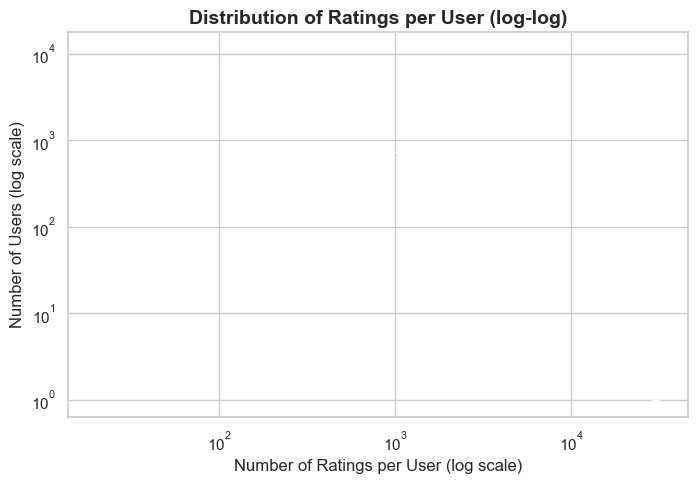

In [5]:
ratings_per_user = ratings.groupby("userId").size().rename("num_ratings")

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(ratings_per_user, bins=60, log_scale=(True, True), color=sns.color_palette(PALETTE, 5)[3], ax=ax)
ax.set_title("Distribution of Ratings per User (log-log)")
ax.set_xlabel("Number of Ratings per User (log scale)")
ax.set_ylabel("Number of Users (log scale)")
save_fig(fig, "user_activity_distribution.png")
plt.show()

Saved figures\user_activity_pareto.png


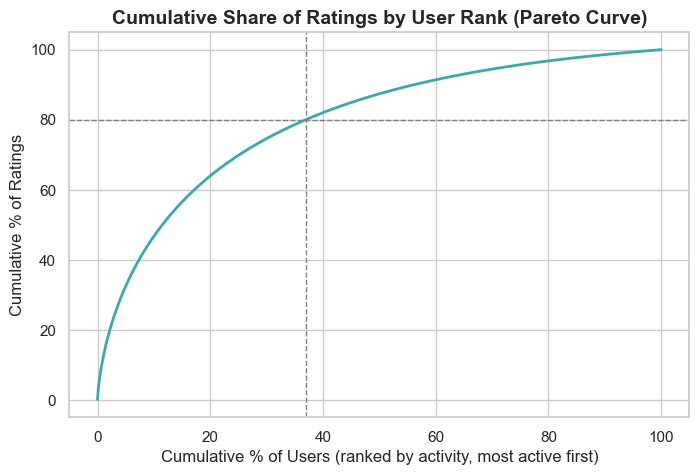

Median ratings per user: 71
Max ratings by a single user: 32,202
36.9% of users account for 80% of all ratings


In [6]:
sorted_counts = ratings_per_user.sort_values(ascending=False)
cum_pct_ratings = sorted_counts.cumsum() / sorted_counts.sum()
cum_pct_users = np.arange(1, len(sorted_counts) + 1) / len(sorted_counts)

n_users_for_80pct = int((cum_pct_ratings <= 0.8).sum())
pct_users_for_80pct = n_users_for_80pct / len(sorted_counts) * 100

fig, ax = plt.subplots(figsize=(8, 5))
color = sns.color_palette(PALETTE, 5)[3]
ax.plot(cum_pct_users * 100, cum_pct_ratings * 100, color=color, linewidth=2)
ax.axhline(80, color="gray", linestyle="--", linewidth=1)
ax.axvline(pct_users_for_80pct, color="gray", linestyle="--", linewidth=1)
ax.set_title("Cumulative Share of Ratings by User Rank (Pareto Curve)")
ax.set_xlabel("Cumulative % of Users (ranked by activity, most active first)")
ax.set_ylabel("Cumulative % of Ratings")
save_fig(fig, "user_activity_pareto.png")
plt.show()

print(f"Median ratings per user: {ratings_per_user.median():.0f}")
print(f"Max ratings by a single user: {ratings_per_user.max():,}")
print(f"{pct_users_for_80pct:.1f}% of users account for 80% of all ratings")

**Insight:** Activity is heavily concentrated in a small "power user" segment — a Pareto pattern where a
small minority of users generate the large majority of ratings, while a long tail of casual users rate
only a handful of movies each. This directly shapes the RL contextual bandit's segmentation: power users
give us enough signal to personalize aggressively, while casual/cold-start users need a different
strategy (e.g. more exploration, more reliance on popularity/genre priors) since we have too little
signal per user to trust personalized predictions.

## 4. Movie Popularity Analysis

The same concentration question applies to movies: are ratings spread evenly across the catalog, or do a
handful of blockbusters dominate while most movies sit in an untouched long tail?

Saved figures\movie_popularity_distribution.png


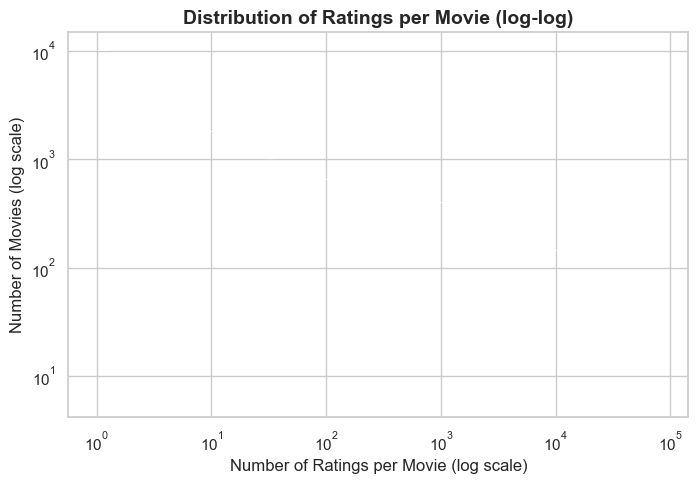

Movies with fewer than 10 ratings: 34,717 (58.8% of rated movies)
Movies with 10,000+ ratings: 588
Median ratings per movie: 6
Most-rated movie: 81,491 ratings


In [7]:
ratings_per_movie = ratings.groupby("movieId").size().rename("num_ratings")

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(ratings_per_movie, bins=60, log_scale=(True, True), color=sns.color_palette(PALETTE, 5)[2], ax=ax)
ax.set_title("Distribution of Ratings per Movie (log-log)")
ax.set_xlabel("Number of Ratings per Movie (log scale)")
ax.set_ylabel("Number of Movies (log scale)")
save_fig(fig, "movie_popularity_distribution.png")
plt.show()

n_long_tail = int((ratings_per_movie < 10).sum())
pct_long_tail = n_long_tail / len(ratings_per_movie) * 100
n_blockbuster = int((ratings_per_movie >= 10000).sum())

print(f"Movies with fewer than 10 ratings: {n_long_tail:,} ({pct_long_tail:.1f}% of rated movies)")
print(f"Movies with 10,000+ ratings: {n_blockbuster:,}")
print(f"Median ratings per movie: {ratings_per_movie.median():.0f}")
print(f"Most-rated movie: {ratings_per_movie.max():,} ratings")

**Insight:** Movie popularity follows an extreme long tail — a large fraction of the catalog has fewer
than 10 ratings, while a small set of blockbusters absorbs a disproportionate share of attention. This is
the classic **popularity bias** problem for recommenders: a model trained naively will over-recommend
already-popular movies (they have the most training signal) and starve the long tail, which is exactly
the content the recommendation engine and RL layer need to learn to surface for the right users to add
real value beyond "just recommend what's popular."

## 5. Genre Analysis

Movies can carry multiple genres, so we explode the `genres` field and look at both how much volume each
genre drives and how well each genre tends to be rated. We weight the average rating per genre by the
number of ratings each movie received, so a single obscure title doesn't skew a genre's average.

Saved figures\genre_frequency.png


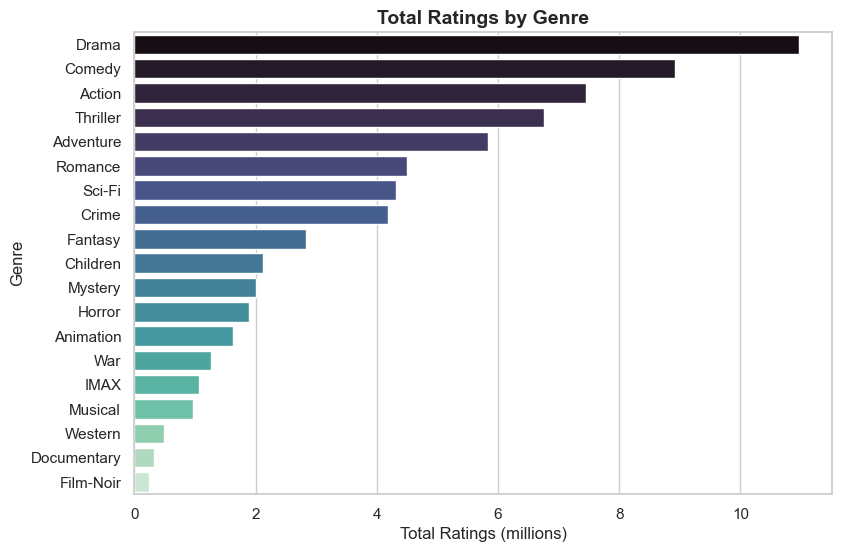

In [8]:
movie_stats = ratings.groupby("movieId").agg(num_ratings=("rating", "size"), rating_sum=("rating", "sum"))

movie_genres = movies[["movieId", "genres"]].copy()
movie_genres = movie_genres[movie_genres["genres"] != "(no genres listed)"]
movie_genres = movie_genres.assign(genre=movie_genres["genres"].str.split("|")).explode("genre")

genre_stats = movie_genres.merge(movie_stats, on="movieId", how="inner")
genre_agg = genre_stats.groupby("genre").agg(
    total_ratings=("num_ratings", "sum"),
    rating_sum=("rating_sum", "sum"),
    num_movies=("movieId", "nunique"),
)
genre_agg["avg_rating"] = genre_agg["rating_sum"] / genre_agg["total_ratings"]
genre_agg = genre_agg.sort_values("total_ratings", ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(
    x=genre_agg["total_ratings"] / 1e6, y=genre_agg.index,
    hue=genre_agg.index, palette=PALETTE, legend=False, ax=ax,
)
ax.set_title("Total Ratings by Genre")
ax.set_xlabel("Total Ratings (millions)")
ax.set_ylabel("Genre")
save_fig(fig, "genre_frequency.png")
plt.show()

Saved figures\genre_avg_rating.png


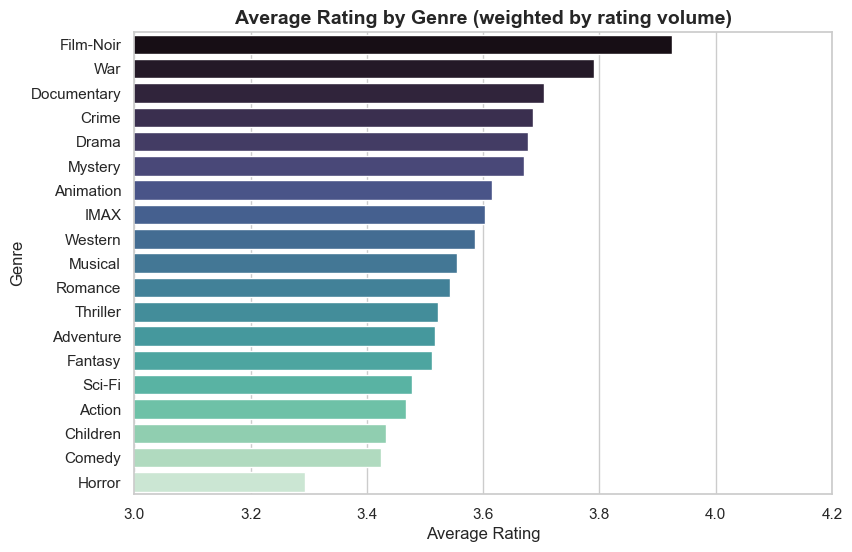

,total_ratings,rating_sum,num_movies,avg_rating
genre,,,,
Drama,10962833,40312360.0,24465,3.677185
Comedy,8926230,30563344.0,16051,3.423992
Action,7446918,25815424.0,6913,3.466592
Thriller,6763272,23826766.0,8330,3.522964
Adventure,5832424,20515228.0,3868,3.517445
Romance,4497291,15932608.0,7305,3.542712
Sci-Fi,4325740,15045544.0,3502,3.478143
Crime,4190259,15441288.0,5024,3.685044
Fantasy,2831585,9943362.0,2667,3.511589


In [9]:
genre_by_rating = genre_agg.sort_values("avg_rating", ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(
    x=genre_by_rating["avg_rating"], y=genre_by_rating.index,
    hue=genre_by_rating.index, palette=PALETTE, legend=False, ax=ax,
)
ax.set_title("Average Rating by Genre (weighted by rating volume)")
ax.set_xlabel("Average Rating")
ax.set_ylabel("Genre")
ax.set_xlim(3, 4.2)
save_fig(fig, "genre_avg_rating.png")
plt.show()

genre_agg.sort_values("total_ratings", ascending=False)

**Insight:** Genre volume is highly uneven — a handful of mainstream genres dominate rating volume, while
niche genres are rated far less often but sometimes score higher on average. High-volume, average-rated
genres are safe bets for broad recommendations; low-volume, high-rated genres are prime candidates for
targeted personalization where the recommendation engine and RL layer can differentiate themselves from
naive popularity-based baselines.

## 6. Temporal Trends

MovieLens ratings were collected continuously over many years, with different waves of user
recruitment. We look at rating volume by month to see when the platform was most active, and average
rating by year to see whether user sentiment has drifted over time.

Saved figures\monthly_rating_volume.png


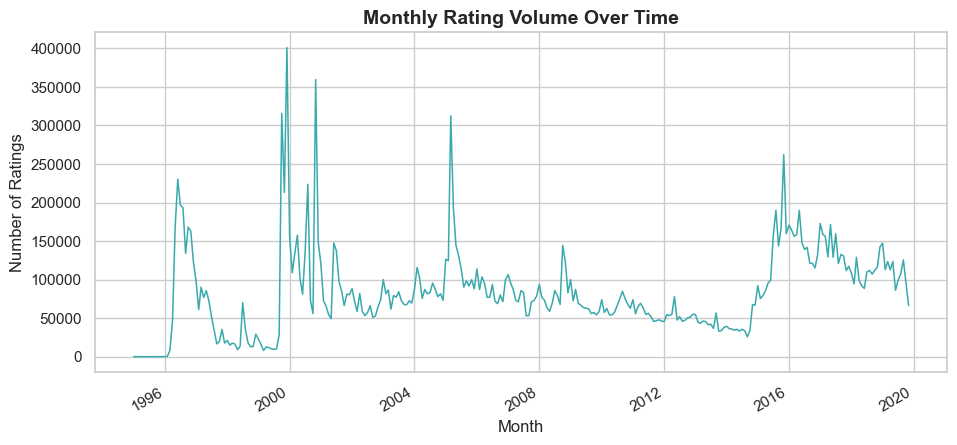

In [10]:
monthly_volume = ratings.groupby("month").size()
monthly_volume.index = monthly_volume.index.to_timestamp()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(monthly_volume.index, monthly_volume.values, color=sns.color_palette(PALETTE, 5)[3], linewidth=1.1)
ax.set_title("Monthly Rating Volume Over Time")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Ratings")
fig.autofmt_xdate()
save_fig(fig, "monthly_rating_volume.png")
plt.show()

Saved figures\yearly_avg_rating_trend.png


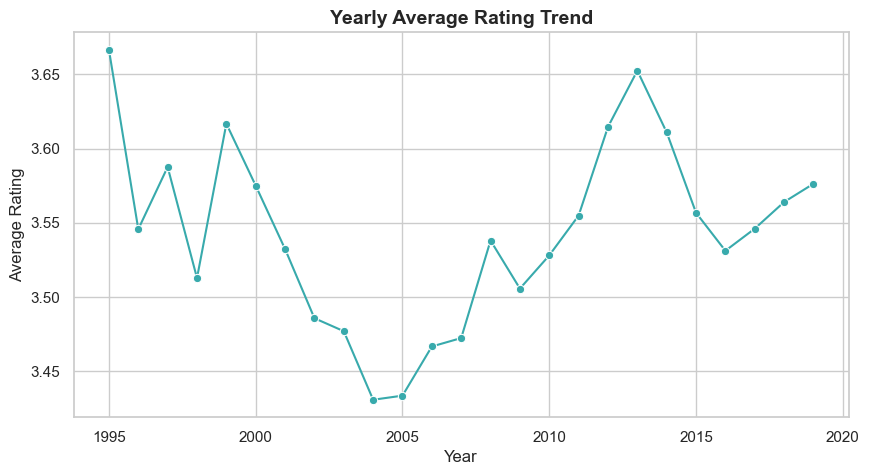

Peak activity month: 1999-12 with 400,997 ratings
Earliest year average rating: 3.67 (1995)
Latest year average rating: 3.58 (2019)


In [11]:
yearly_avg = ratings.groupby("year")["rating"].mean()

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(x=yearly_avg.index, y=yearly_avg.values, marker="o", color=sns.color_palette(PALETTE, 5)[3], ax=ax)
ax.set_title("Yearly Average Rating Trend")
ax.set_xlabel("Year")
ax.set_ylabel("Average Rating")
save_fig(fig, "yearly_avg_rating_trend.png")
plt.show()

peak_month = monthly_volume.idxmax()
print(f"Peak activity month: {peak_month.strftime('%Y-%m')} with {int(monthly_volume.max()):,} ratings")
print(f"Earliest year average rating: {yearly_avg.iloc[0]:.2f} ({yearly_avg.index[0]})")
print(f"Latest year average rating: {yearly_avg.iloc[-1]:.2f} ({yearly_avg.index[-1]})")

**Insight:** Rating volume comes in distinct bursts tied to MovieLens's user-recruitment waves rather
than a smooth organic curve, and the yearly average rating drifts over time rather than staying flat.
This is exactly the signal our LightGBM forecasting module needs to model: demand and sentiment are
non-stationary, so any forecast has to account for both trend and the platform-level shocks that create
these bursts, not assume a stable baseline.

## 7. Genre Trends Over Time

Aggregate genre popularity hides a more useful signal: which genres are *gaining* traction and which are
*fading*. We compute rating volume per genre per year (via movie-level year counts joined to genre, which
avoids exploding all 25M ratings row-by-row) and compare each genre's share of ratings early in the
dataset's history against its share in the most recent years.

Saved figures\genre_trends_over_time.png


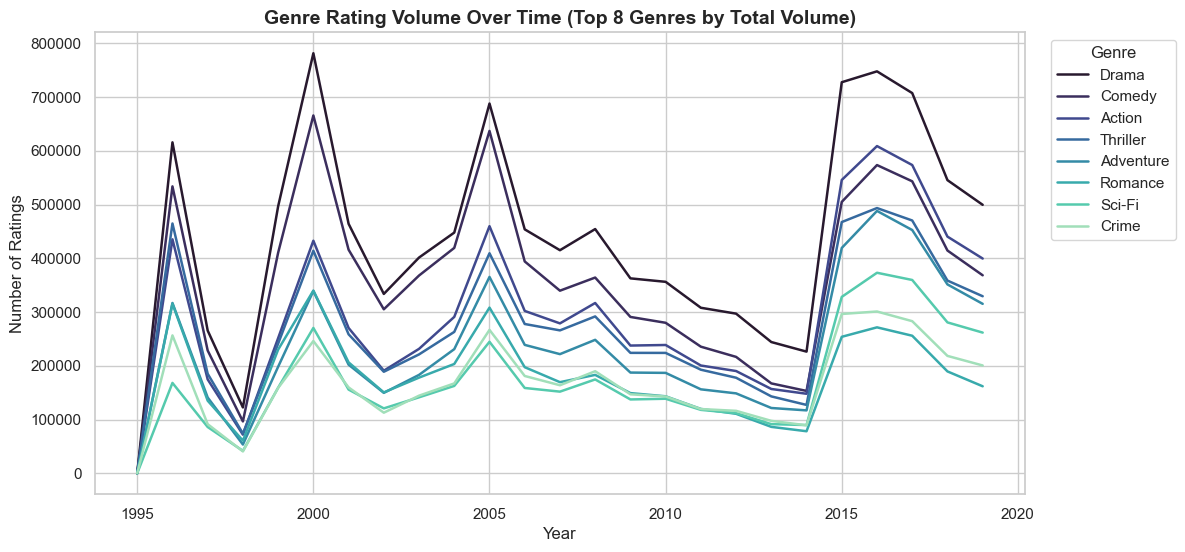

In [12]:
movie_year_counts = ratings.groupby(["movieId", "year"]).size().reset_index(name="count")
genre_year = movie_year_counts.merge(movie_genres[["movieId", "genre"]], on="movieId", how="inner")
genre_year_agg = genre_year.groupby(["year", "genre"])["count"].sum().reset_index()

top_genres = genre_agg.sort_values("total_ratings", ascending=False).head(8).index.tolist()
trend_pivot = (
    genre_year_agg[genre_year_agg["genre"].isin(top_genres)]
    .pivot(index="year", columns="genre", values="count")
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(12, 6))
palette = sns.color_palette(PALETTE, len(top_genres))
for color, genre in zip(palette, top_genres):
    ax.plot(trend_pivot.index, trend_pivot[genre], label=genre, color=color, linewidth=1.8)
ax.set_title("Genre Rating Volume Over Time (Top 8 Genres by Total Volume)")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Ratings")
ax.legend(title="Genre", bbox_to_anchor=(1.02, 1), loc="upper left")
save_fig(fig, "genre_trends_over_time.png")
plt.show()

Saved figures\genre_trend_change.png


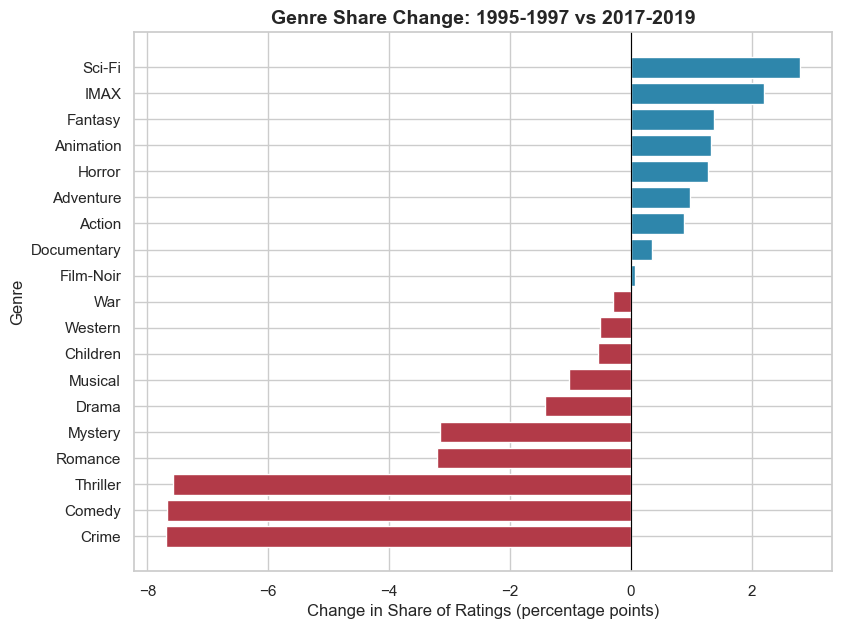

Rising genres (largest share gain):
genre
Horror       1.273057
Animation    1.324646
Fantasy      1.378996
IMAX         2.197057
Sci-Fi       2.798830

Declining genres (largest share loss):
genre
Crime      -7.690202
Comedy     -7.677658
Thriller   -7.583481
Romance    -3.203786
Mystery    -3.163448


In [13]:
genre_year_agg["year_total"] = genre_year_agg.groupby("year")["count"].transform("sum")
genre_year_agg["share"] = genre_year_agg["count"] / genre_year_agg["year_total"]

years_sorted = sorted(genre_year_agg["year"].unique())
early_years = years_sorted[:3]
recent_years = years_sorted[-3:]

early_share = genre_year_agg[genre_year_agg["year"].isin(early_years)].groupby("genre")["share"].mean()
recent_share = genre_year_agg[genre_year_agg["year"].isin(recent_years)].groupby("genre")["share"].mean()

trend_change = (recent_share - early_share).dropna().sort_values()
trend_change_pp = trend_change * 100

fig, ax = plt.subplots(figsize=(9, 7))
colors = ["#b23a48" if v < 0 else "#2e86ab" for v in trend_change_pp.values]
ax.barh(trend_change_pp.index, trend_change_pp.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title(f"Genre Share Change: {early_years[0]}-{early_years[-1]} vs {recent_years[0]}-{recent_years[-1]}")
ax.set_xlabel("Change in Share of Ratings (percentage points)")
ax.set_ylabel("Genre")
save_fig(fig, "genre_trend_change.png")
plt.show()

print("Rising genres (largest share gain):")
print(trend_change_pp.tail(5).to_string())
print("\nDeclining genres (largest share loss):")
print(trend_change_pp.head(5).to_string())

**Insight:** Genre share is not static — some genres have meaningfully grown their share of ratings over
the dataset's history while others have faded, independent of the platform-wide volume bursts seen in
Section 6. This year-over-year genre share movement is the core training signal for the trend
forecasting component: it's what lets a LightGBM model learn "genre X is gaining traction" as a
feature-based pattern instead of forecasting each movie in isolation.

## 8. User-Item Matrix Sparsity

Collaborative filtering ultimately operates on a user x movie matrix. We quantify how much of that
matrix is actually observed.

Saved figures\matrix_sparsity.png


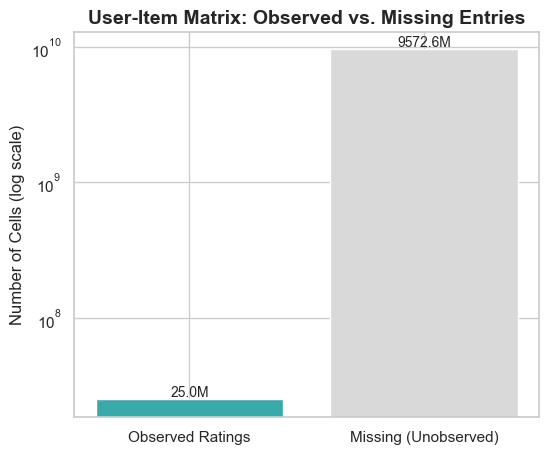

User-item matrix size: 162,541 users x 59,047 movies = 9,597,558,427 possible entries
Observed ratings: 25,000,095
Sparsity: 99.7395%  (density: 0.2605%)


In [14]:
n_users_u = ratings["userId"].nunique()
n_movies_u = ratings["movieId"].nunique()
n_possible = n_users_u * n_movies_u
n_actual = len(ratings)
sparsity = 1 - (n_actual / n_possible)
density = 1 - sparsity

fig, ax = plt.subplots(figsize=(6, 5))
bar_colors = [sns.color_palette(PALETTE, 5)[3], "#d9d9d9"]
ax.bar(["Observed Ratings", "Missing (Unobserved)"], [n_actual, n_possible - n_actual], color=bar_colors)
ax.set_title("User-Item Matrix: Observed vs. Missing Entries")
ax.set_ylabel("Number of Cells (log scale)")
ax.set_yscale("log")
for i, v in enumerate([n_actual, n_possible - n_actual]):
    ax.text(i, v, f"{v/1e6:.1f}M", ha="center", va="bottom", fontsize=10)
save_fig(fig, "matrix_sparsity.png")
plt.show()

print(f"User-item matrix size: {n_users_u:,} users x {n_movies_u:,} movies = {n_possible:,} possible entries")
print(f"Observed ratings: {n_actual:,}")
print(f"Sparsity: {sparsity*100:.4f}%  (density: {density*100:.4f}%)")

**Insight:** The user-item matrix is over 99% sparse — the overwhelming majority of user/movie pairs have
no observed rating at all. This is precisely why naive approaches (e.g. a simple lookup table, or
item-average baselines) fail: there's almost nothing to look up for most pairs. It's the core justification
for Neural Collaborative Filtering, which learns dense latent embeddings that generalize to unseen
user/movie pairs, and for an RL layer that must make good decisions under genuine uncertainty rather than
assuming full information.

## 9. Top Movies

Finally, we look at the catalog from two different angles: which movies are rated the *most* (popularity),
and which are rated the *best* among movies with a credible sample size (quality). Comparing the two tells
us whether "popular" and "good" are the same thing in this dataset.

Saved figures\top20_most_rated_movies.png


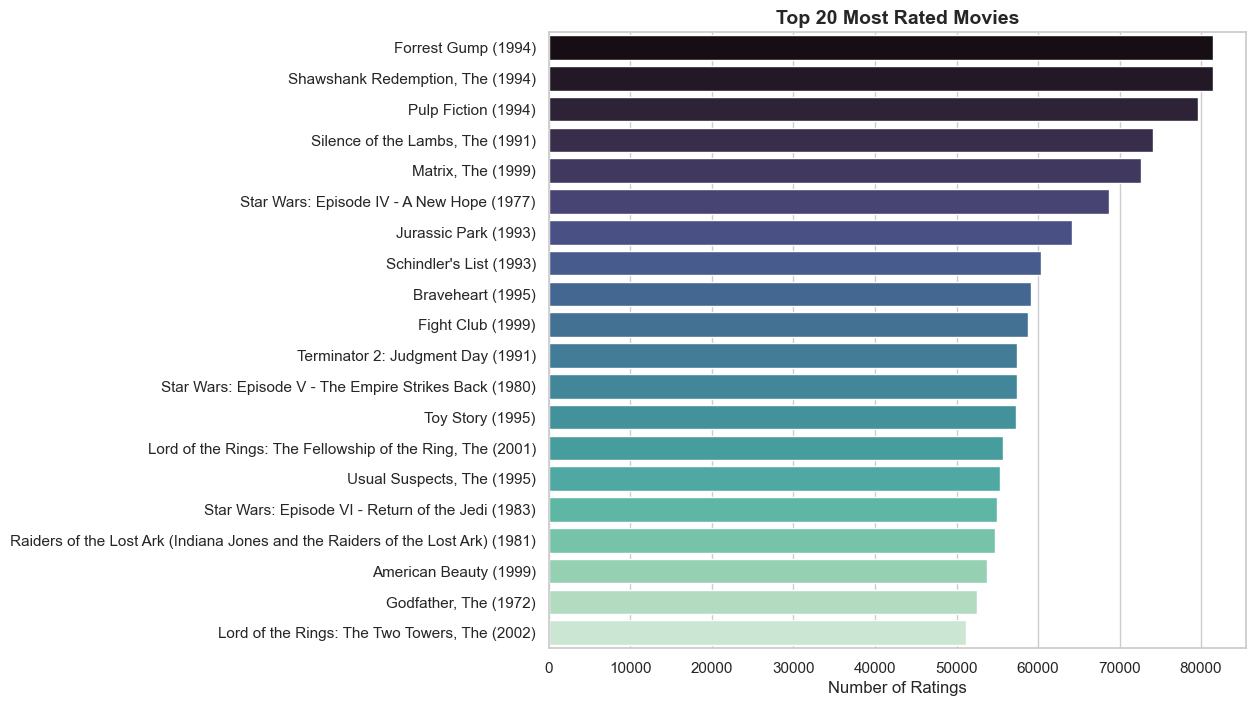

In [15]:
movie_stats_named = movie_stats.merge(movies[["movieId", "title"]], on="movieId", how="left")
movie_stats_named["avg_rating"] = movie_stats_named["rating_sum"] / movie_stats_named["num_ratings"]

top20_popular = movie_stats_named.sort_values("num_ratings", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 8))
sns.barplot(
    x=top20_popular["num_ratings"], y=top20_popular["title"],
    hue=top20_popular["title"], palette=PALETTE, legend=False, ax=ax,
)
ax.set_title("Top 20 Most Rated Movies")
ax.set_xlabel("Number of Ratings")
ax.set_ylabel("")
save_fig(fig, "top20_most_rated_movies.png")
plt.show()

Saved figures\top20_highest_rated_movies.png


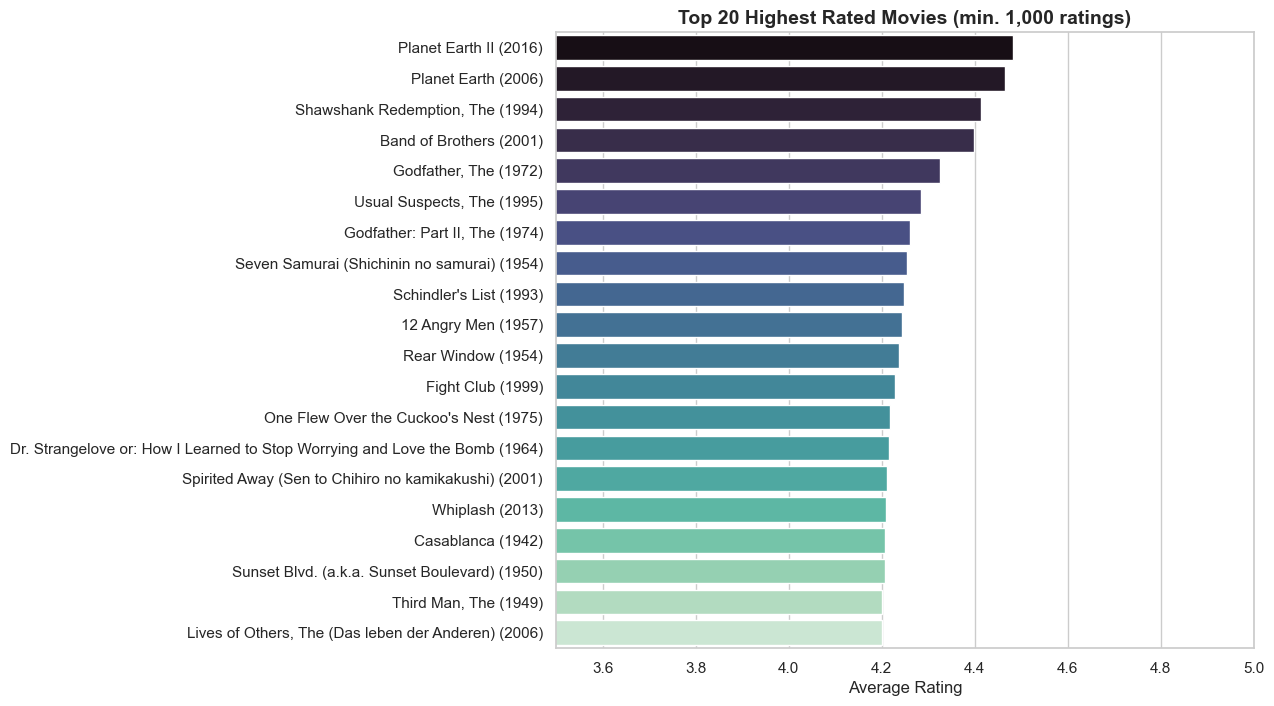

In [16]:
min_ratings_threshold = 1000
qualified = movie_stats_named[movie_stats_named["num_ratings"] >= min_ratings_threshold]
top20_quality = qualified.sort_values("avg_rating", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 8))
sns.barplot(
    x=top20_quality["avg_rating"], y=top20_quality["title"],
    hue=top20_quality["title"], palette=PALETTE, legend=False, ax=ax,
)
ax.set_title(f"Top 20 Highest Rated Movies (min. {min_ratings_threshold:,} ratings)")
ax.set_xlabel("Average Rating")
ax.set_ylabel("")
ax.set_xlim(3.5, 5.0)
save_fig(fig, "top20_highest_rated_movies.png")
plt.show()

Saved figures\popularity_vs_quality.png


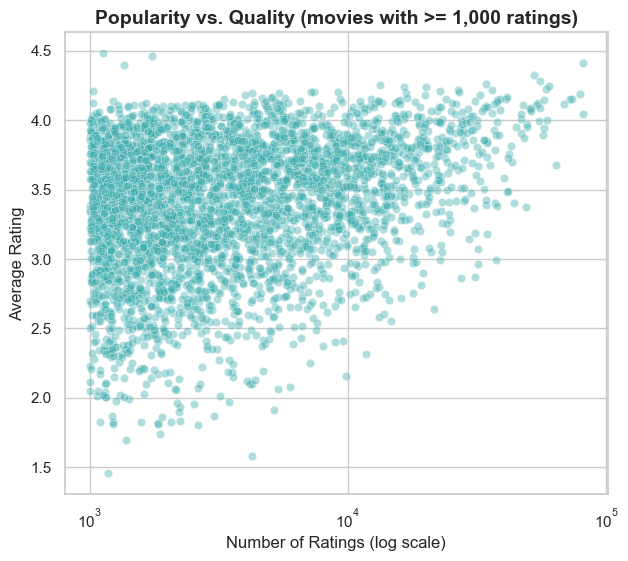

Overlap between Top 20 most-rated and Top 20 highest-rated: 5 movies
Correlation (num_ratings vs avg_rating, among movies with >= 1,000 ratings): 0.265


In [17]:
overlap = set(top20_popular["movieId"]) & set(top20_quality["movieId"])
corr = qualified["num_ratings"].corr(qualified["avg_rating"])

sample = qualified.sample(n=min(5000, len(qualified)), random_state=42)

fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(
    x=sample["num_ratings"], y=sample["avg_rating"],
    alpha=0.4, color=sns.color_palette(PALETTE, 5)[3], ax=ax,
)
ax.set_xscale("log")
ax.set_title("Popularity vs. Quality (movies with >= 1,000 ratings)")
ax.set_xlabel("Number of Ratings (log scale)")
ax.set_ylabel("Average Rating")
save_fig(fig, "popularity_vs_quality.png")
plt.show()

print(f"Overlap between Top 20 most-rated and Top 20 highest-rated: {len(overlap)} movies")
print(f"Correlation (num_ratings vs avg_rating, among movies with >= {min_ratings_threshold:,} ratings): {corr:.3f}")

**Insight:** The most-rated movies and the highest-rated movies are largely *different* lists, and the
correlation between rating volume and average rating (among movies with a credible sample size) is weak.
Popularity and quality are not the same signal. This is a direct warning against a recommender that
defaults to "most popular" as its fallback strategy — it validates investing in a personalization layer
(NCF) and a bandit-driven exploration strategy (RL) that can surface high-quality, lower-visibility movies
to the users who would actually rate them highly.

## Summary & Next Steps

- **Trend Forecasting:** Sections 6 and 7 show clear non-stationary, genre-level demand shifts over time
  — the LightGBM forecaster should be trained on genre/time features, not static popularity.
- **Recommendation Engine:** Sections 4, 8, and 9 show extreme sparsity and popularity bias — NCF's
  learned embeddings are needed to generalize beyond the small set of movies with dense signal, and
  evaluation should explicitly check for popularity bias rather than just accuracy.
- **RL Optimization:** Sections 2 and 3 show skewed rewards and highly uneven user activity — the
  contextual bandit needs segment-aware exploration (power users vs. cold-start users) and a reward
  definition calibrated to the generous rating scale, not a raw midpoint threshold.

All figures used in this notebook are saved to `notebooks/figures/` for reuse in reports and the
dashboard.